In [71]:
# Core libraries for data handling
import os
import pandas as pd
import numpy as np

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point, Polygon

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# System tools for importing local helper scripts
import sys

# Add project folder so Python can locate helper modules
sys.path.append("Camera_Level_Analysis")

# Import helper function
from get_common_names import get_common_names

# Optional notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot style
sns.set_theme(style="whitegrid")

In [251]:
# File paths and global settings
# ------------------------------------------------------------
CLEANED_PATH = "cleaned"
PREPROCESSED_PATH = "preprocessed_data"
OUTPUT_PATH = "../outputs"
USA_MAP_PATH = "../data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"

# -----------------------------
# Input datasets
# -----------------------------

# Cleaned Snapshot USA observations
SSUSA_CSV = "ssusa_cleaned.csv"

# Cleaned IUCN species range polygons
IUCN_DATA = "iucn_cleaned.shp"

# 1-km camera footprint polygons
CAMERA_FOOTPRINTS = "ssusa_camera_footprints_1km.geojson"

# 1-km array footprint polygons
ARRAY_FOOTPRINTS = "ssusa_array_footprints_1km.geojson"

# -----------------------------
# Basemap file
# -----------------------------

# U.S. shapefile for map backgrounds
US_SHAPE = "../data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"

# -----------------------------
# Coordinate reference system
# -----------------------------

# Albers Equal Area projection (commonly used for US spatial analysis)
AEA = "EPSG:5070"

SLOT_BOXA = (6.37, 4.90)

In [190]:
# Read SSUSA observations table
ssusa = pd.read_csv(f"{CLEANED_PATH}/{SSUSA_CSV}", low_memory=False)

# Read spatial datasets
iucn = gpd.read_file(f"{CLEANED_PATH}/{IUCN_DATA}")
camera_footprints = gpd.read_file(f"{PREPROCESSED_PATH}/{CAMERA_FOOTPRINTS}")
array_footprints = gpd.read_file(f"{PREPROCESSED_PATH}/{ARRAY_FOOTPRINTS}")
world = gpd.read_file(USA_MAP_PATH).to_crs(3857)

# Quick checks
print("SSUSA rows:", len(ssusa))
print("IUCN polygons:", len(iucn))
print("Camera footprints:", len(camera_footprints))
print("Array footprints:", len(array_footprints))

SSUSA rows: 713319
IUCN polygons: 733
Camera footprints: 7340
Array footprints: 262


In [29]:
# Load U.S. basemap for maps
us_map = gpd.read_file(US_SHAPE)

# Preview
us_map.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,FJI,0,Fiji,FJI,0,Fiji,FJI,0,Fiji,Fiji,FJI,Fiji,None,Fiji,FJ,Republic of Fiji,None,Fiji,None,None,Fiji,None,5,1,2,2,889953.0,11,2019,5496,2019,6. Developing region,4. Lower middle income,FJ,FJ,FJ,FJI,FJI,242,242,242,FJ,FJI,23424813,23424813,Exact WOE match as country,FJI,None,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,FJI,-99,-99,Oceania,Oceania,Melanesia,East Asia & Pacific,4,4,4,-99,1,0.0,3.0,8.0,177.975427,-17.826099,1159320625,Q712,فيجي,ফিজি,Fidschi,Fiji,Fiyi,فیجی,Fidji,Φίτζι,פיג'י,फ़िजी,Fidzsi-szigetek,Fiji,Figi,フィジー,피지,Fiji,Fidżi,Fiji,Фиджи,Fiji,Fiji,Фіджі,فجی,Fiji,斐济,斐濟,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,TZA,0,Tanzania,TZA,0,Tanzania,TZA,0,Tanzania,Tanzania,TZA,Tanzania,None,Tanz.,TZ,United Republic of Tanzania,None,Tanzania,None,None,Tanzania,None,3,6,2,2,58005463.0,16,2019,63177,2019,7. Least developed region,5. Low income,TZ,TZ,TZ,TZA,TZA,834,834,834,TZ,TZA,23424973,23424973,Exact WOE match as country,TZA,None,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,TZA,-99,-99,Africa,Africa,Eastern Africa,Sub-Saharan Africa,8,8,5,-99,1,0.0,3.0,8.0,34.959183,-6.051866,1159321337,Q924,تنزانيا,তানজানিয়া,Tansania,Tanzania,Tanzania,تانزانیا,Tanzanie,Τανζανία,טנזניה,तंज़ानिया,Tanzánia,Tanzania,Tanzania,タンザニア,탄자니아,Tanzania,Tanzania,Tanzânia,Танзания,Tanzania,Tanzanya,Танзанія,تنزانیہ,Tanzania,坦桑尼亚,坦尚尼亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,SAH,0,Western Sahara,SAH,0,Western Sahara,SAH,1,W. Sahara,Western Sahara,B28,W. Sahara,None,W. Sah.,WS,Sahrawi Arab Democratic Republic,None,Western Sahara,None,Self admin.; Claimed by Morocco,Western Sahara,None,4,7,4,4,603253.0,11,2017,907,2007,7. Least develope

In [30]:
# Confirm CRS for each spatial layer before overlays/intersections
print("IUCN CRS:", iucn.crs)
print("Camera CRS:", camera_footprints.crs)
print("Array CRS:", array_footprints.crs)
print("US Map CRS:", us_map.crs)


# Use the CRS from IUCN data as the shared coordinate system
camera_footprints = camera_footprints.to_crs(iucn.crs)
array_footprints = array_footprints.to_crs(iucn.crs)
us_map = us_map.to_crs(iucn.crs)

IUCN CRS: EPSG:4326
Camera CRS: EPSG:5070
Array CRS: EPSG:5070
US Map CRS: EPSG:4326


In [31]:
def make_camera_id(lon, lat):
    return f"{lon:.8f}_{lat:.8f}"

In [32]:
# Ensure coordinates are numeric
ssusa["Longitude"] = pd.to_numeric(ssusa["Longitude"], errors="coerce")
ssusa["Latitude"] = pd.to_numeric(ssusa["Latitude"], errors="coerce")

# Create footprint ID for each record
ssusa["camera_fp_id"] = ssusa.apply(
    lambda row: make_camera_id(row["Longitude"], row["Latitude"]),
    axis=1
)

# Preview results
ssusa[["Longitude", "Latitude", "camera_fp_id"]].head()

,Longitude,Latitude,camera_fp_id
0,-136.2225,59.42643,-136.22250000_59.42643000
1,-136.2225,59.42643,-136.22250000_59.42643000
2,-136.2225,59.42643,-136.22250000_59.42643000
3,-136.2225,59.42643,-136.22250000_59.42643000
4,-136.2225,59.42643,-136.22250000_59.42643000


In [35]:
# Camera footprints already contains camera_fp_id
camera_footprints.head()

,Longitude,Latitude,camera_fp_id,geometry
0,-136.22250,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4..."
1,-135.92880,59.39905,-135.92880000_59.39905000,"POLYGON ((-135.91418 59.40308, -135.91361 59.4..."
2,-135.84097,59.38020,-135.84097000_59.38020000,"POLYGON ((-135.82635 59.38422, -135.82578 59.3..."
3,-136.30461,59.42641,-136.30461000_59.42641000,"POLYGON ((-136.29001 59.43047, -136.28943 59.4..."
4,-136.15141,59.41195,-136.15141000_59.41195000,"POLYGON ((-136.1368 59.416, -136.13623 59.4150..."


In [36]:
# Verify camera IDs align across datasets
# -------------------------------------------------------

# Count unique IDs in each dataset
print("SSUSA unique camera IDs:", ssusa["camera_fp_id"].nunique())
print("Footprint unique camera IDs:", camera_footprints["camera_fp_id"].nunique())

# Check overlap
matched_ids = set(ssusa["camera_fp_id"]).intersection(
    set(camera_footprints["camera_fp_id"])
)

print("Matching IDs:", len(matched_ids))

SSUSA unique camera IDs: 7340
Footprint unique camera IDs: 7340
Matching IDs: 7340


### IUCN Data Prepare for matching to Camera Footprints

In [37]:
# Check IUCN columns before processing
# -------------------------------------------------------

# View all column names
print(iucn.columns)

# Preview first few rows
iucn.head()

Index(['id_no', 'sci_name', 'presence', 'origin', 'seasonal', 'category', 'compiler', 'yrcompiled', 'citation',
       'subspecies', 'subpop', 'source', 'island', 'tax_comm', 'dist_comm', 'generalisd', 'legend', 'class', 'order',
       'family', 'genus', 'marine', 'terrestria', 'freshwater', 'body_mass', 'ab_thres', 'scope_flag', 'geometry'],
      dtype='object')


,id_no,sci_name,presence,origin,seasonal,category,compiler,yrcompiled,citation,subspecies,subpop,source,island,tax_comm,dist_comm,generalisd,legend,class,order,family,genus,marine,terrestria,freshwater,body_mass,ab_thres,scope_flag,geometry
0,699,cuniculus paca,1,3,1,LC,IUCN SSC Small Mammal Specialist Group,2016,IUCN SSC Small Mammal Specialist Group,None,None,None,Cuba,None,None,0,Extant & Introduced (resident),MAMMALIA,RODENTIA,CUNICULIDAE,Cuniculus,false,true,false,9000.00,True,None,"POLYGON ((-75 20.70021, -74.99594 20.70142, -7..."
1,699,cuniculus paca,1,1,1,LC,IUCN SSC Small Mammal Specialist Group,2016,IUCN SSC Small Mammal Specialist Group,None,None,None,None,None,None,0,Extant (resident),MAMMALIA,RODENTIA,CUNICULIDAE,Cuniculus,false,true,false,9000.00,True,None,"MULTIPOLYGON (((-49.33396 -28.92112, -49.34433..."
2,914,alouatta pigra,1,1,1,EN,IUCN,2020,IUCN (International Union for Conservation of ...,None,None,None,None,None,None,0,Extant (resident),MAMMALIA,PRIMATES,ATELIDAE,Alouatta,false,true,false,9386.03,True,None,"MULTIPOLYGON (((-87.87473 18.2655, -87.87526 1..."
3,1149,ammospermophilus nelsoni,1,1,1,EN,IUCN SSC Small Mammal Specialist Group,2017,IUCN SSC Small Mammal Specialist Group,None,None,None,None,None,None,0,Extant (resident),MAMMALIA,RODENTIA,SCIURIDAE,Ammospermophilus,false,true,false,157.46,False,None,"POLYGON ((-120.32787 35.78064, -120.31875 35.7..."
4,1677,antilocapra americana,1,1,1,LC,NatureServe,2008,NatureServe,None,None,None,None,None,None,0,Extant (resident),MAMMALIA,ARTIODACTYLA,ANTILOCAPRIDAE,Antilocapra,false,true,false,45375.00,True,None,"MULTIPOLYGON (((-101.1829 23.06214, -101.4751 ..."


In [38]:
iucn.groupby("ab_thres")["body_mass"].describe()

# Optional quick preview of values
iucn[["ab_thres", "body_mass"]].head()

,ab_thres,body_mass
0,True,9000.00
1,True,9000.00
2,True,9386.03
3,False,157.46
4,True,45375.00


In [42]:
# Filter IUCN to threshold-qualified species
# -------------------------------------------------------

# Keep only rows where ab_thres is True
iucn_filtered = iucn[iucn["ab_thres"] == True].copy()

# Confirm results
print("Original rows:", len(iucn))
print("Filtered rows:", len(iucn_filtered))

# Check remaining values
print(iucn_filtered["ab_thres"].value_counts(dropna=False))
print("Rows retained:", len(iucn_filtered))

Original rows: 733
Filtered rows: 202
ab_thres
True    202
Name: count, dtype: int64
Rows retained: 202


### Dissolve IUCN Polygons by Species

`sci_name` is the scientific species name column.

We dissolve by `sci_name` so all polygons for the same species are merged into one combined range.  
This gives one row per species and helps avoid duplicate matches in overlap analysis.

In [43]:
print("Empty geometries:", iucn_filtered.geometry.is_empty.sum())
print("Missing geometries:", iucn_filtered.geometry.isna().sum())
print("Invalid geometries:", (~iucn_filtered.geometry.is_valid).sum())
# Count unique scientific species names
print("Unique species in iucn_filtered:", iucn_filtered["sci_name"].nunique())

Empty geometries: 0
Missing geometries: 0
Invalid geometries: 0
Unique species in iucn_filtered: 127


In [44]:
# Combine all polygons for each species into one range
# -------------------------------------------------------

# Fix invalid geometries before dissolving
iucn_filtered = iucn_filtered.copy()
iucn_filtered["geometry"] = iucn_filtered.geometry.make_valid()

# Remove empty or missing geometries
iucn_filtered = iucn_filtered[
    (~iucn_filtered.geometry.is_empty) &
    (iucn_filtered.geometry.notna())
].copy()

# Dissolve by scientific name
iucn_species = iucn_filtered.dissolve(by="sci_name").reset_index()

print("Original rows after geometry cleaning:", len(iucn_filtered))
print("Species rows:", len(iucn_species))

/Users/neelima/miniconda3/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)


Original rows after geometry cleaning: 202
Species rows: 127


In [45]:
# Count invalid geometries by species
bad = iucn_filtered.loc[~iucn_filtered.geometry.is_valid, ["sci_name", "geometry"]]

print("Invalid rows:", len(bad))
print(bad["sci_name"].value_counts())

Invalid rows: 0
Series([], Name: count, dtype: int64)


### Match IUCN Species Ranges to Camera Footprints

The spatial join returns one row for each camera-species match.  
If a camera intersects multiple species ranges, it will appear in multiple rows.

In [46]:
# Spatial join: species predicted at each camera footprint
camera_iucn = gpd.sjoin(
    camera_footprints,
    iucn_species[["sci_name", "geometry"]],
    how="inner",
    predicate="intersects"
)

print("Predicted camera-species matches:", len(camera_iucn))

camera_iucn.head()

Predicted camera-species matches: 109627


,Longitude,Latitude,camera_fp_id,geometry,index_right,sci_name
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",126,vulpes vulpes
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",11,canis lupus
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",0,alces alces
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",19,clethrionomys rutilus
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",40,gulo gulo


In [47]:
# Inspect spatial join output
# -------------------------------------------------------

# Number of unique cameras with at least one predicted species
print("Matched cameras:", camera_iucn["camera_fp_id"].nunique())

# Number of unique predicted species
print("Unique Predicted species:", camera_iucn["sci_name"].nunique())

# Preview joined table
camera_iucn.head()

Matched cameras: 7223
Unique Predicted species: 68


,Longitude,Latitude,camera_fp_id,geometry,index_right,sci_name
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",126,vulpes vulpes
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",11,canis lupus
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",0,alces alces
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",19,clethrionomys rutilus
0,-136.2225,59.42643,-136.22250000_59.42643000,"POLYGON ((-136.20789 59.43048, -136.20732 59.4...",40,gulo gulo


### Create calculated values for Jaccard similarity calculations 

In [48]:
# Predicted species per camera
# -------------------------------------------------------

camera_predicted = (
    camera_iucn
    .groupby("camera_fp_id")["sci_name"]
    .unique()
    .reset_index()
)

# Preview
camera_predicted.head()

,camera_fp_id,sci_name
0,-100.23311000_35.92725000,"[dasypus novemcinctus, vulpes vulpes, odocoile..."
1,-100.24179000_35.92768000,"[dasypus novemcinctus, vulpes vulpes, odocoile..."
2,-100.24180200_35.92767900,"[dasypus novemcinctus, vulpes vulpes, odocoile..."
3,-100.24181000_35.92775000,"[dasypus novemcinctus, vulpes vulpes, odocoile..."
4,-100.24212710_35.92756100,"[dasypus novemcinctus, vulpes vulpes, odocoile..."


In [20]:
print(ssusa.columns.tolist())

['Year', 'Project', 'Camera_Trap_Array', 'Deployment_ID', 'Sequence_ID', 'Start_Time', 'End_Time', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Common_Name', 'Age', 'Sex', 'Group_Size', 'Site_Name', 'Start_Date', 'End_Date', 'Survey_Nights', 'Latitude', 'Longitude', 'Habitat', 'Development_Level', 'Feature_Type', 'Species_Name', 'Body_Mass_g', 'Above_Threshold', 'Scope_Flag', 'camera_fp_id']


In [49]:
# Observed species per camera
# -------------------------------------------------------

camera_observed = (
    ssusa
    .groupby("camera_fp_id")["Species_Name"]
    .unique()
    .reset_index()
)

camera_observed.head()

,camera_fp_id,Species_Name
0,-100.23311000_35.92725000,"[procyon lotor, odocoileus virginianus]"
1,-100.24179000_35.92768000,"[odocoileus virginianus, procyon lotor]"
2,-100.24180200_35.92767900,"[canis latrans, odocoileus hemionus, procyon l..."
3,-100.24181000_35.92775000,[odocoileus virginianus]
4,-100.24212710_35.92756100,[odocoileus virginianus]


### Compare Observed vs Predicted Species

Merge observed and predicted species lists for each camera so we can compare detections with IUCN expectations.

In [55]:
# Merge observed and predicted species by camera
# -------------------------------------------------------

camera_compare = camera_observed.merge(
    camera_predicted,
    on="camera_fp_id",
    how="outer",
    suffixes=("_observed", "_predicted")
)

camera_compare.head()

,camera_fp_id,Species_Name,sci_name
0,-100.23311000_35.92725000,"[procyon lotor, odocoileus virginianus]","[dasypus novemcinctus, vulpes vulpes, odocoile..."
1,-100.24179000_35.92768000,"[odocoileus virginianus, procyon lotor]","[dasypus novemcinctus, vulpes vulpes, odocoile..."
2,-100.24180200_35.92767900,"[canis latrans, odocoileus hemionus, procyon l...","[dasypus novemcinctus, vulpes vulpes, odocoile..."
3,-100.24181000_35.92775000,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile..."
4,-100.24212710_35.92756100,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile..."


In [56]:
# Rename columns for clarity
# -------------------------------------------------------

camera_compare = camera_compare.rename(
    columns={
        "Species_Name": "observed_species",
        "sci_name": "predicted_species"
    }
)

camera_compare.head()

,camera_fp_id,observed_species,predicted_species
0,-100.23311000_35.92725000,"[procyon lotor, odocoileus virginianus]","[dasypus novemcinctus, vulpes vulpes, odocoile..."
1,-100.24179000_35.92768000,"[odocoileus virginianus, procyon lotor]","[dasypus novemcinctus, vulpes vulpes, odocoile..."
2,-100.24180200_35.92767900,"[canis latrans, odocoileus hemionus, procyon l...","[dasypus novemcinctus, vulpes vulpes, odocoile..."
3,-100.24181000_35.92775000,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile..."
4,-100.24212710_35.92756100,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile..."


In [62]:
camera_compare["observed_species"] = camera_compare["observed_species"].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else []
)

camera_compare["predicted_species"] = camera_compare["predicted_species"].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else []
)

# Now count species
camera_compare["n_observed"] = camera_compare["observed_species"].apply(len)
camera_compare["n_predicted"] = camera_compare["predicted_species"].apply(len)






In [61]:
camera_compare.head(50)

,camera_fp_id,observed_species,predicted_species,n_observed,n_predicted
0,-100.23311000_35.92725000,"[procyon lotor, odocoileus virginianus]","[dasypus novemcinctus, vulpes vulpes, odocoile...",2,18
1,-100.24179000_35.92768000,"[odocoileus virginianus, procyon lotor]","[dasypus novemcinctus, vulpes vulpes, odocoile...",2,18
2,-100.24180200_35.92767900,"[canis latrans, odocoileus hemionus, procyon l...","[dasypus novemcinctus, vulpes vulpes, odocoile...",4,18
3,-100.24181000_35.92775000,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile...",1,18
4,-100.24212710_35.92756100,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile...",1,18
5,-100.24547220_35.93334600,"[odocoileus virginianus, canis latrans, odocoi...","[dasypus novemcinctus, vulpes vulpes, odocoile...",3,18
6,-100.24674700_35.93237100,"[canis latrans, odocoileus hemionus, odocoileu...","[dasypus novemcinctus, vulpes vulpes, odocoile...",4,18
7,-100.24802800_47.41722000,[canis latrans],"[vulpes vulpes, odocoileus virginianus, sylvil...",1,14
8,-100.25287100_47.42695700,"[lepus townsendii, canis latrans]","[vulpes vulpes, odocoileus virginianus, sylvil...",2,14
9,-100.25684700_35.89623200,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile...",1,18


In [63]:
# Compare observed vs predicted species at each camera
# -------------------------------------------------------

def compare_species(row):
    observed = set(row["observed_species"])
    predicted = set(row["predicted_species"])
    
    return pd.Series({
        "n_shared": len(observed & predicted),          # observed and predicted
        "n_only_observed": len(observed - predicted),   # detected but not predicted
        "n_only_predicted": len(predicted - observed)   # predicted but not detected
    })

camera_compare[[
    "n_shared",
    "n_only_observed",
    "n_only_predicted"
]] = camera_compare.apply(compare_species, axis=1)

camera_compare.head()

,camera_fp_id,observed_species,predicted_species,n_observed,n_predicted,n_shared,n_only_observed,n_only_predicted
0,-100.23311000_35.92725000,"[procyon lotor, odocoileus virginianus]","[dasypus novemcinctus, vulpes vulpes, odocoile...",2,18,2,0,16
1,-100.24179000_35.92768000,"[odocoileus virginianus, procyon lotor]","[dasypus novemcinctus, vulpes vulpes, odocoile...",2,18,2,0,16
2,-100.24180200_35.92767900,"[canis latrans, odocoileus hemionus, procyon l...","[dasypus novemcinctus, vulpes vulpes, odocoile...",4,18,4,0,14
3,-100.24181000_35.92775000,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile...",1,18,1,0,17
4,-100.24212710_35.92756100,[odocoileus virginianus],"[dasypus novemcinctus, vulpes vulpes, odocoile...",1,18,1,0,17


In [64]:
# Overall summary of camera comparisons
# -------------------------------------------------------

summary = pd.DataFrame({
    "metric": [
        "Total cameras",
        "Mean observed species",
        "Mean predicted species",
        "Mean shared species",
        "Mean observed only",
        "Mean predicted only"
    ],
    "value": [
        len(camera_compare),
        camera_compare["n_observed"].mean(),
        camera_compare["n_predicted"].mean(),
        camera_compare["n_shared"].mean(),
        camera_compare["n_only_observed"].mean(),
        camera_compare["n_only_predicted"].mean()
    ]
})

summary

,metric,value
0,Total cameras,7340.000000
1,Mean observed species,4.264169
2,Mean predicted species,14.935559
3,Mean shared species,3.689918
4,Mean observed only,0.574251
5,Mean predicted only,11.245640


In [65]:
# Jaccard similarity between observed and predicted species
# -------------------------------------------------------

def jaccard_similarity(row):
    observed = set(row["observed_species"])
    predicted = set(row["predicted_species"])
    
    union = observed | predicted
    intersection = observed & predicted
    
    if len(union) == 0:
        return np.nan
    
    return len(intersection) / len(union)

camera_compare["jaccard"] = camera_compare.apply(
    jaccard_similarity,
    axis=1
)

camera_compare[[
    "camera_fp_id",
    "jaccard"
]].head()

,camera_fp_id,jaccard
0,-100.23311000_35.92725000,0.111111
1,-100.24179000_35.92768000,0.111111
2,-100.24180200_35.92767900,0.222222
3,-100.24181000_35.92775000,0.055556
4,-100.24212710_35.92756100,0.055556


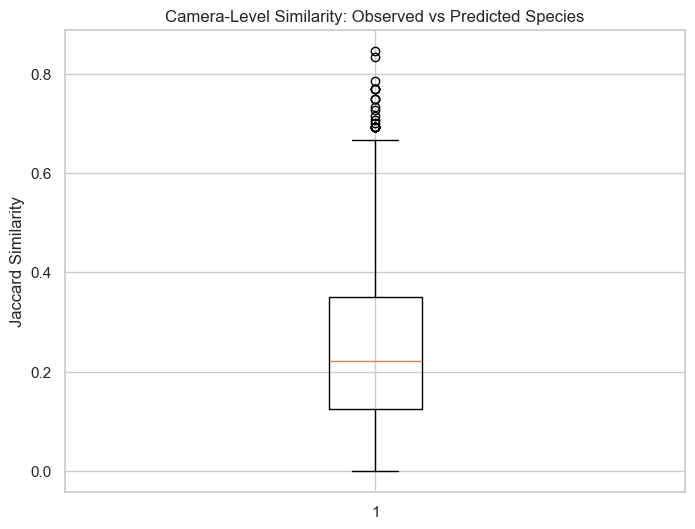

In [68]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    camera_compare["jaccard"].dropna(),
    vert=True
)

plt.ylabel("Jaccard Similarity")
plt.title("Camera-Level Similarity: Observed vs Predicted Species")

plt.show()

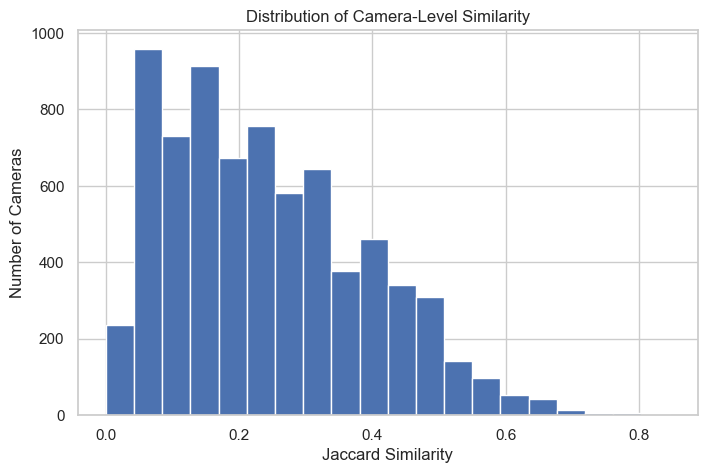

In [69]:
plt.figure(figsize=(8,5))
plt.hist(camera_compare["jaccard"].dropna(), bins=20)
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of Cameras")
plt.title("Distribution of Camera-Level Similarity")
plt.show()

## Compare Jaccard Similarity for Camera Level and Array Level

In [73]:
# ------------------------------------------------------------
# Load array footprints
# ------------------------------------------------------------
# Set array ID column
# Set array ID column
array_col = "Camera_Trap_Array"

# Load array footprints
array_footprints = gpd.read_file(os.path.join(PREPROCESSED_PATH, ARRAY_FOOTPRINTS))

# Reproject to same CRS as IUCN species ranges
array_footprints = array_footprints.to_crs(iucn_species.crs)

print("Rows:", len(array_footprints))
print("CRS:", array_footprints.crs)
print(array_footprints.columns.tolist())

Rows: 262
CRS: EPSG:4326
['Camera_Trap_Array', 'geometry']


In [74]:
# Spatial join: predicted species ranges intersecting each array footprint
array_iucn = gpd.sjoin(
    array_footprints,
    iucn_species[["sci_name", "geometry"]],
    how="inner",
    predicate="intersects"
)



In [75]:

print("Total array footprints:", array_footprints[array_col].nunique())
print("Arrays with IUCN matches:", array_iucn[array_col].nunique())
print("Total array-species matches:", len(array_iucn))
print("Unique predicted species:", array_iucn["sci_name"].nunique())

array_iucn[[array_col, "sci_name"]].head()

Total array footprints: 262
Arrays with IUCN matches: 256
Total array-species matches: 4065
Unique predicted species: 68


,Camera_Trap_Array,sci_name
0,ARNWR,vulpes vulpes
0,ARNWR,odocoileus virginianus
0,ARNWR,sylvilagus floridanus
0,ARNWR,sylvilagus palustris
0,ARNWR,lynx rufus


### Get calculated colunms for calculating Jaccard 

Group the spatial join output so each camera trap array has a list of IUCN-predicted species.

In [77]:
# Predicted species list for each camera trap array
# -------------------------------------------------------

array_predicted = (
    array_iucn
    .groupby(array_col)["sci_name"]
    .unique()
    .reset_index()
)

array_predicted.head()

,Camera_Trap_Array,sci_name
0,ARNWR,"[vulpes vulpes, odocoileus virginianus, sylvil..."
1,AandM,"[leopardus pardalis, nasua narica, pecari taja..."
2,Abilene,"[pecari tajacu, dasypus novemcinctus, odocoile..."
3,AbitaFlats,"[dasypus novemcinctus, vulpes vulpes, odocoile..."
4,Afognak,"[alexandromys oeconomus, ursus arctos]"


In [78]:
# Observed species list for each camera trap array
# -------------------------------------------------------

array_observed = (
    ssusa
    .groupby(array_col)["Species_Name"]
    .unique()
    .reset_index()
)

array_observed.head()

,Camera_Trap_Array,Species_Name
0,ARNWR,"[ursus americanus, odocoileus virginianus, sci..."
1,AandM,"[lepus californicus, lynx rufus, pecari tajacu..."
2,Abilene,"[odocoileus virginianus, sciurus niger, procyo..."
3,AbitaFlats,"[lynx rufus, canis latrans, sciurus carolinens..."
4,Afognak,"[martes americana, ursus arctos, cervus elaphu..."


In [79]:
# Merge observed and predicted species by array
# -------------------------------------------------------

array_compare = array_observed.merge(
    array_predicted,
    on=array_col,
    how="outer"
)

array_compare = array_compare.rename(
    columns={
        "Species_Name": "observed_species",
        "sci_name": "predicted_species"
    }
)

array_compare.head()

,Camera_Trap_Array,observed_species,predicted_species
0,ARNWR,"[ursus americanus, odocoileus virginianus, sci...","[vulpes vulpes, odocoileus virginianus, sylvil..."
1,AandM,"[lepus californicus, lynx rufus, pecari tajacu...","[leopardus pardalis, nasua narica, pecari taja..."
2,Abilene,"[odocoileus virginianus, sciurus niger, procyo...","[pecari tajacu, dasypus novemcinctus, odocoile..."
3,AbitaFlats,"[lynx rufus, canis latrans, sciurus carolinens...","[dasypus novemcinctus, vulpes vulpes, odocoile..."
4,Afognak,"[martes americana, ursus arctos, cervus elaphu...","[alexandromys oeconomus, ursus arctos]"


In [80]:
# Replace missing observed/predicted species lists
# -------------------------------------------------------

array_compare["observed_species"] = array_compare["observed_species"].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else []
)

array_compare["predicted_species"] = array_compare["predicted_species"].apply(
    lambda x: x if isinstance(x, (list, np.ndarray)) else []
)

array_compare.head()

,Camera_Trap_Array,observed_species,predicted_species
0,ARNWR,"[ursus americanus, odocoileus virginianus, sci...","[vulpes vulpes, odocoileus virginianus, sylvil..."
1,AandM,"[lepus californicus, lynx rufus, pecari tajacu...","[leopardus pardalis, nasua narica, pecari taja..."
2,Abilene,"[odocoileus virginianus, sciurus niger, procyo...","[pecari tajacu, dasypus novemcinctus, odocoile..."
3,AbitaFlats,"[lynx rufus, canis latrans, sciurus carolinens...","[dasypus novemcinctus, vulpes vulpes, odocoile..."
4,Afognak,"[martes americana, ursus arctos, cervus elaphu...","[alexandromys oeconomus, ursus arctos]"


In [81]:
# Calculate Jaccard similarity for each camera trap array
# -------------------------------------------------------

array_compare["jaccard"] = array_compare.apply(
    jaccard_similarity,
    axis=1
)

array_compare[[array_col, "jaccard"]].head()

,Camera_Trap_Array,jaccard
0,ARNWR,0.692308
1,AandM,0.529412
2,Abilene,0.600000
3,AbitaFlats,0.400000
4,Afognak,0.125000


In [82]:
array_compare["jaccard"].describe()

count    262.000000
mean       0.509346
std        0.165884
min        0.000000
25%        0.421053
50%        0.529412
75%        0.618132
max        0.923077
Name: jaccard, dtype: float64

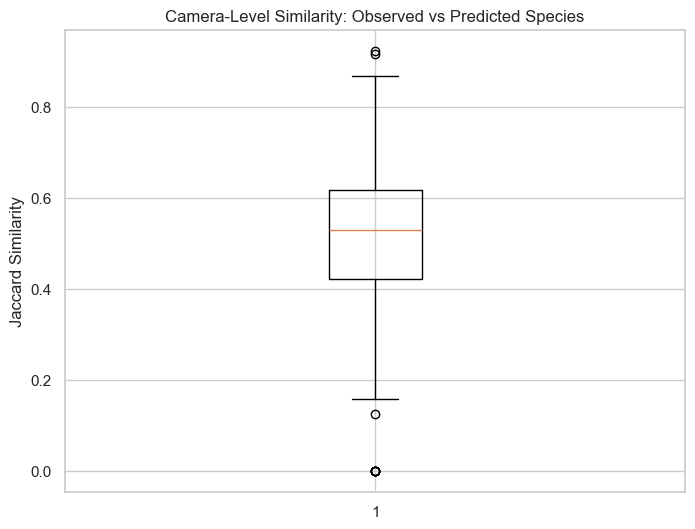

In [84]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    array_compare["jaccard"].dropna(),
    vert=True
)

plt.ylabel("Jaccard Similarity")
plt.title("Camera-Level Similarity: Observed vs Predicted Species")

plt.show()

### Plot Jaccard Similarity for camera level and array level 

In [87]:
plot_df = pd.concat([
    pd.DataFrame({
        "level": "Camera",
        "jaccard": camera_compare["jaccard"]
    }),
    pd.DataFrame({
        "level": "Array",
        "jaccard": array_compare["jaccard"]
    })
], ignore_index=True)



In [121]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Georgia", "Times New Roman", "DejaVu Serif"]

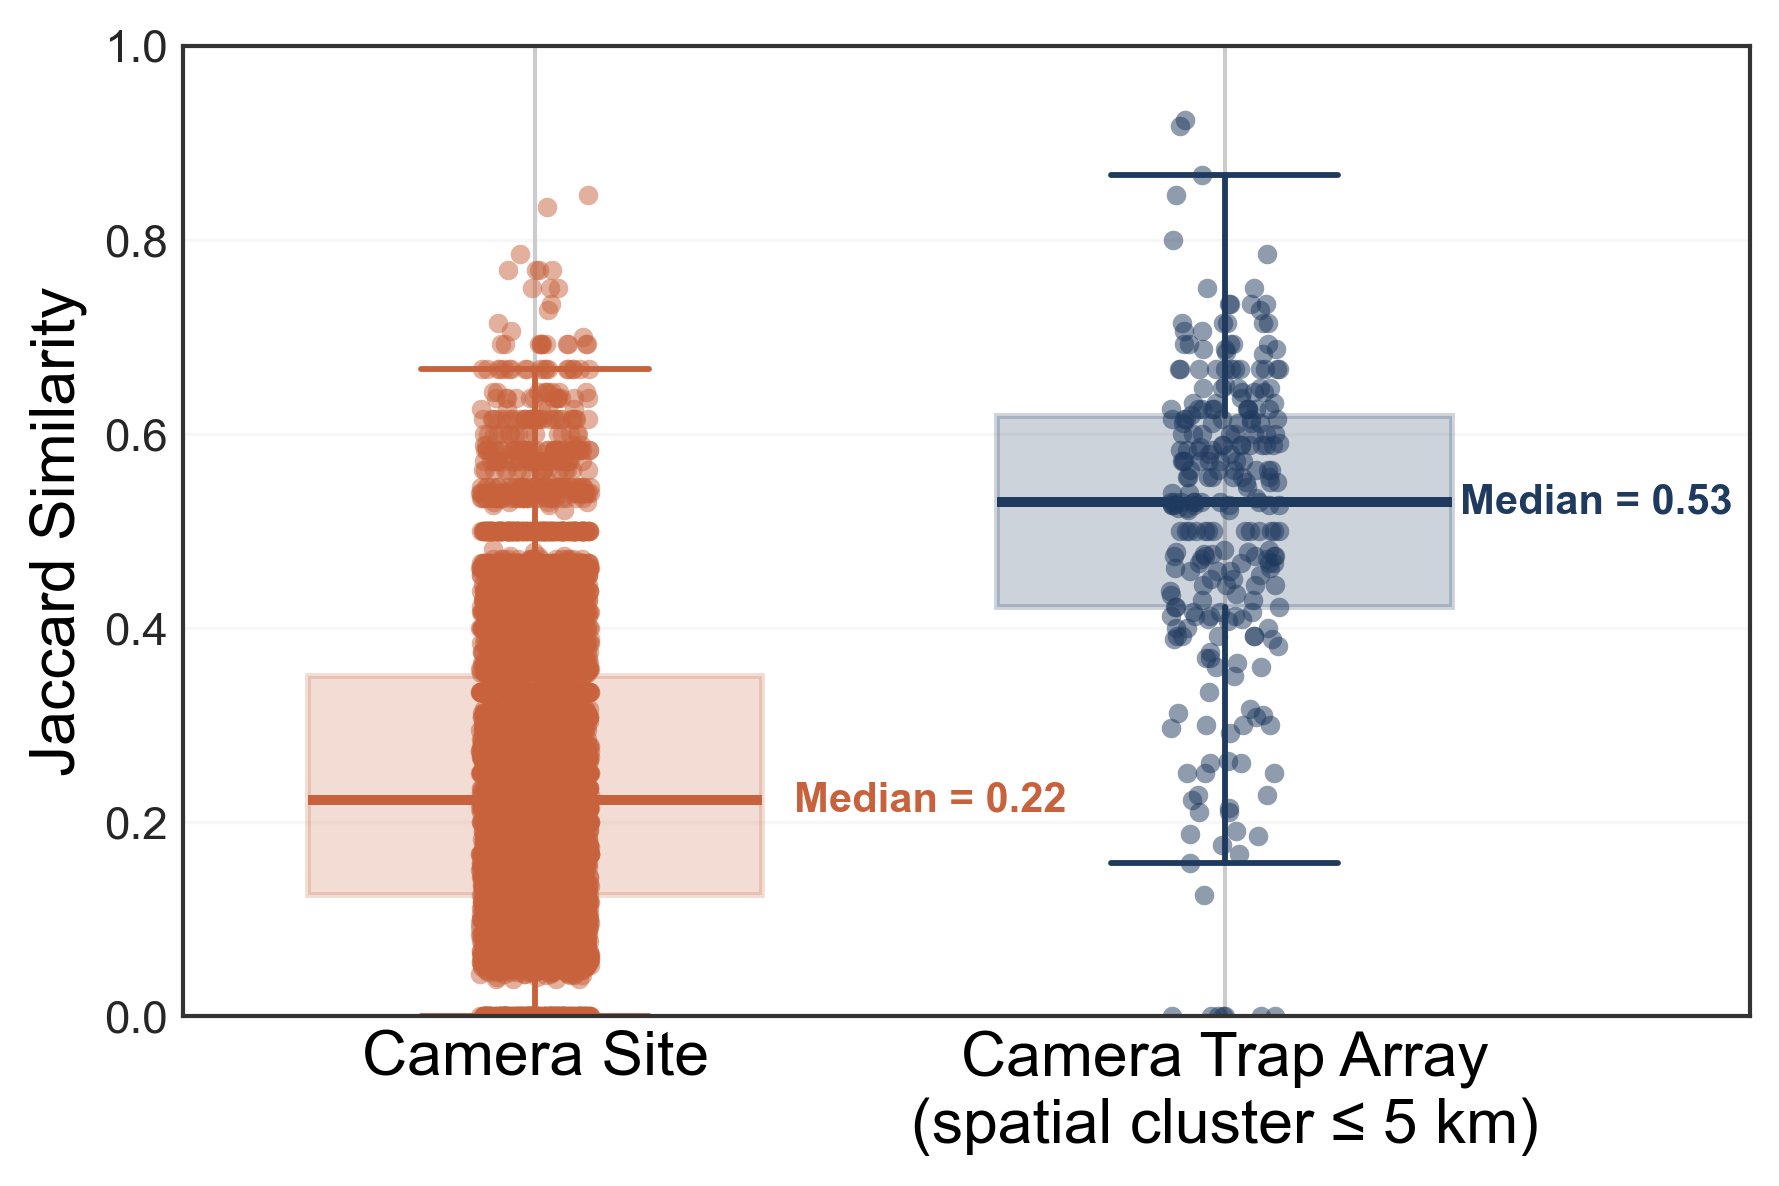

In [337]:
# Move both plots left by shifting box/scatter positions and x-limits left

# Pull values
camera_vals = plot_df.loc[plot_df["level"] == "Camera", "jaccard"].dropna().values
array_vals  = plot_df.loc[plot_df["level"] == "Array", "jaccard"].dropna().values

camera_median = np.median(camera_vals)
array_median  = np.median(array_vals)

# Colors
bg_color = "white"
camera_color = "#C7623C"
array_color  = "#1F3A5F"
text_color = "black"

fig, ax = plt.subplots(figsize=SLOT_BOXA, dpi=300, facecolor=bg_color)

plt.style.use('seaborn-v0_8-whitegrid')
ax.set_facecolor(bg_color)

# SHIFTED LEFT positions
pos1 = 0.8
pos2 = 1.68

bp = ax.boxplot(
    [camera_vals, array_vals],
    positions=[pos1, pos2],
    widths=0.58,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=2.4),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    boxprops=dict(linewidth=1.4)
)

# Color styling
for patch, c in zip(bp["boxes"], [camera_color, array_color]):
    patch.set_facecolor(c)
    patch.set_alpha(0.22)
    patch.set_edgecolor(c)

for median, c in zip(bp["medians"], [camera_color, array_color]):
    median.set_color(c)

for whisker, c in zip(bp["whiskers"],
                      [camera_color, camera_color, array_color, array_color]):
    whisker.set_color(c)

for cap, c in zip(bp["caps"],
                  [camera_color, camera_color, array_color, array_color]):
    cap.set_color(c)

# Jitter points aligned with shifted boxes
rng = np.random.default_rng(42)
x_camera = pos1 + rng.uniform(-0.07, 0.07, len(camera_vals))
x_array  = pos2 + rng.uniform(-0.07, 0.07, len(array_vals))

ax.scatter(x_camera, camera_vals, s=22, alpha=0.50, color=camera_color, linewidths=0)
ax.scatter(x_array,  array_vals,  s=22, alpha=0.50, color=array_color, linewidths=0)

# Median labels
ax.text(pos1 + 0.33, camera_median, f"Median = {camera_median:.2f}",
        ha="left", va="center", fontsize=10, fontweight="bold",
        color=camera_color)

ax.text(pos2 + 0.30, array_median, f"Median = {array_median:.2f}",
        ha="left", va="center", fontsize=10, fontweight="bold",
        color=array_color)

# Labels
ax.set_xticks([pos1, pos2])
ax.set_xticklabels([
    "Camera Site",
    "Camera Trap Array\n(spatial cluster ≤ 5 km)"
], fontsize=15, fontname="Arial", color=text_color)

ax.set_ylabel("Jaccard Similarity", fontsize=15, fontname="Arial", color=text_color)

ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.01, 0.2))

# LEFT-SHIFTED x-axis space
ax.set_xlim(0.35, 2.35)

ax.grid(axis="y", alpha=0.14, linewidth=0.8)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('#333333')

plt.subplots_adjust(left=0.14, right=0.96, top=0.88, bottom=0.22)

plt.show()

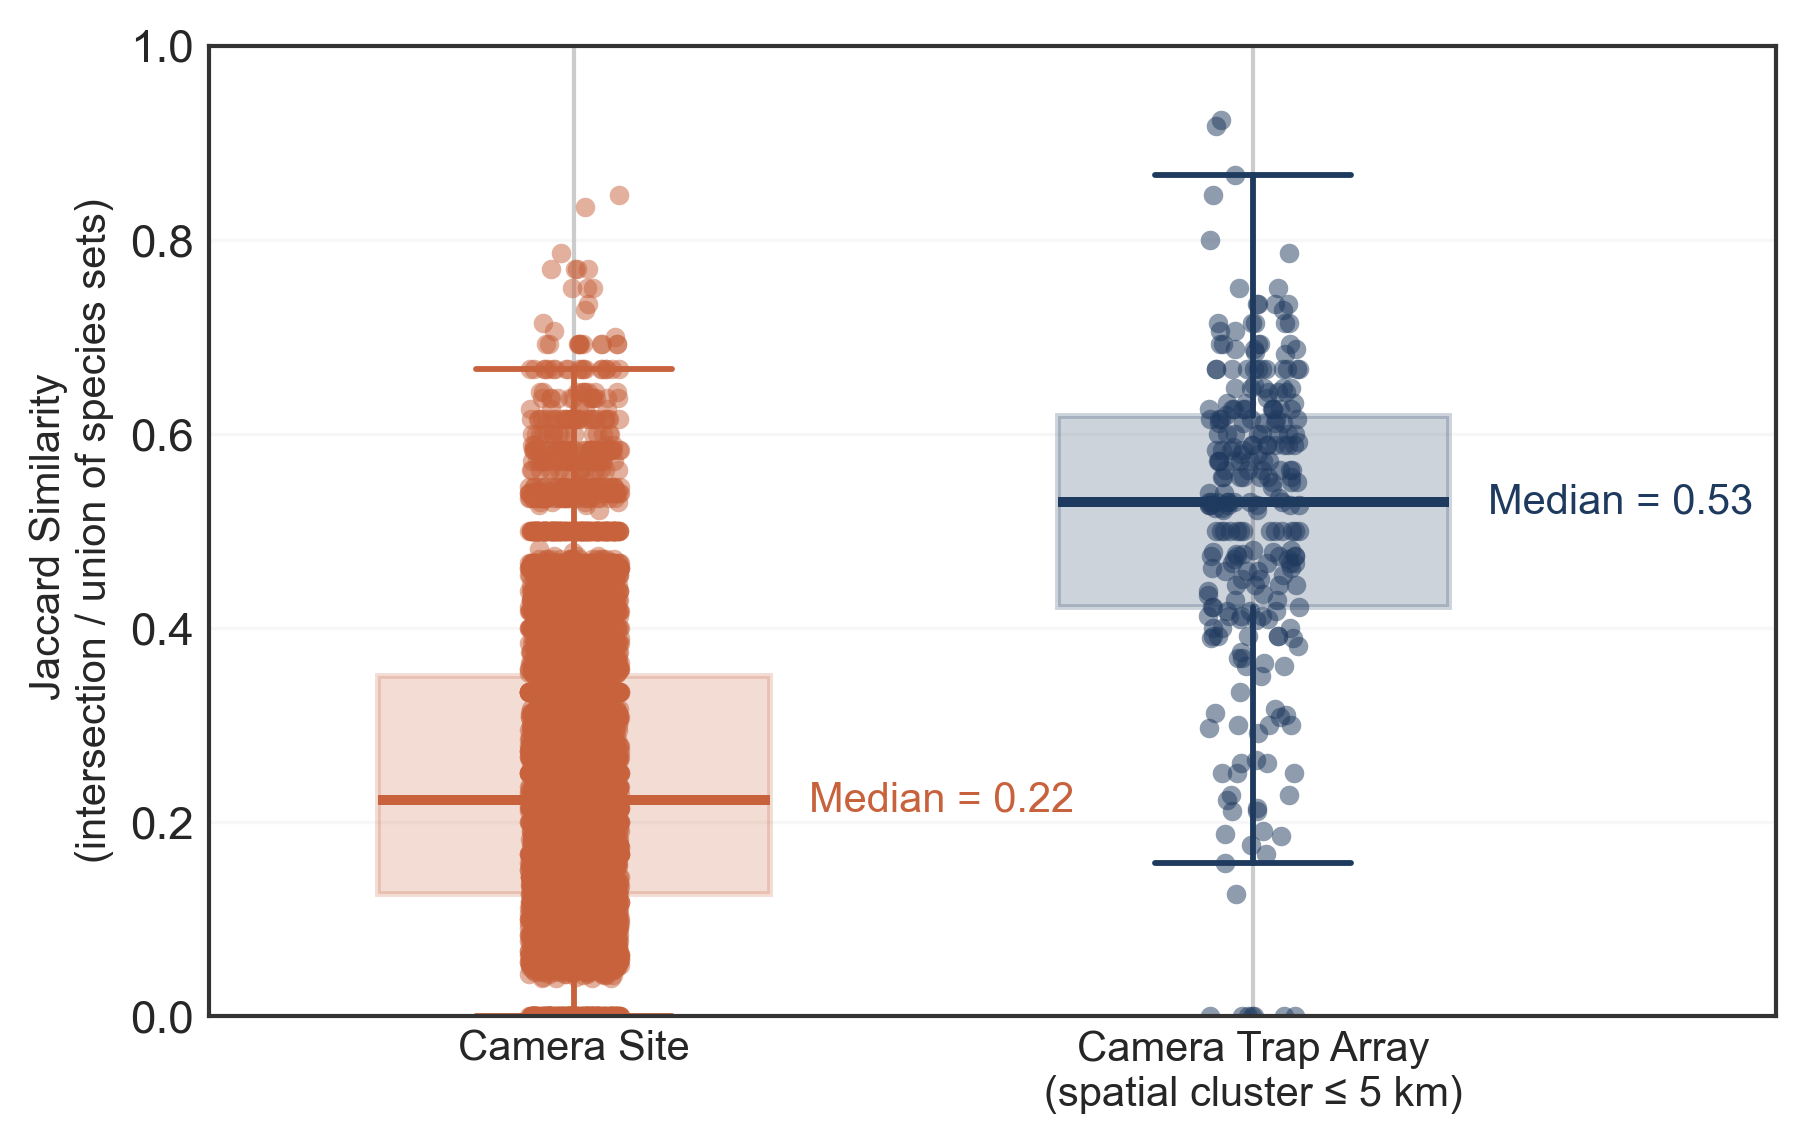

In [ ]:
camera_vals = plot_df.loc[plot_df["level"] == "Camera", "jaccard"].dropna().values
array_vals  = plot_df.loc[plot_df["level"] == "Array", "jaccard"].dropna().values

camera_median = np.median(camera_vals)
array_median  = np.median(array_vals)

# Colors
bg_color = "#FDFBF3"
camera_color = "#C7623C"
array_color  = "#1F3A5F"

# Reduced width figure
fig, ax = plt.subplots(figsize=SLOT_BOXA, dpi=300)

plt.style.use('seaborn-v0_8-whitegrid')
#ax.set_facecolor(bg_color)

# Closer boxes
bp = ax.boxplot(
    [camera_vals, array_vals],
    positions=[1.00, 1.52],
    widths=0.30,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=2.4),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    boxprops=dict(linewidth=1.4)
)

# Color styling
for patch, c in zip(bp["boxes"], [camera_color, array_color]):
    patch.set_facecolor(c)
    patch.set_alpha(0.22)
    patch.set_edgecolor(c)

for median, c in zip(bp["medians"], [camera_color, array_color]):
    median.set_color(c)

for whisker, c in zip(bp["whiskers"],
                      [camera_color, camera_color, array_color, array_color]):
    whisker.set_color(c)

for cap, c in zip(bp["caps"],
                  [camera_color, camera_color, array_color, array_color]):
    cap.set_color(c)

# Tighter jitter
rng = np.random.default_rng(42)
x_camera = 1.00 + rng.uniform(-0.035, 0.035, len(camera_vals))
x_array  = 1.52 + rng.uniform(-0.035, 0.035, len(array_vals))

ax.scatter(x_camera, camera_vals, s=22, alpha=0.50, color=camera_color, linewidths=0)
ax.scatter(x_array,  array_vals,  s=22, alpha=0.50, color=array_color, linewidths=0)

# Median labels
ax.text(1.18, camera_median, f"Median = {camera_median:.2f}",
        ha="left", va="center", fontsize=10,
        color=camera_color)

ax.text(1.7, array_median, f"Median = {array_median:.2f}",
        ha="left", va="center", fontsize=10,
        color=array_color)

# Labels
ax.set_xticks([1.00, 1.52])
ax.set_xticklabels([
    "Camera Site",
    "Camera Trap Array\n(spatial cluster ≤ 5 km)"
], fontsize=10)

ax.set_ylabel("Jaccard Similarity \n(intersection / union of species sets)", fontsize=10)



# Scale
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.01, 0.2))

# Reduced plot width
ax.set_xlim(0.72, 1.92)

# Grid
ax.grid(axis="y", alpha=0.14, linewidth=0.8)
ax.set_axisbelow(True)

# Border
for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('#333333')

plt.subplots_adjust(left=0.14, right=0.96, top=0.88, bottom=0.22)

plt.show()

### Plot Jaccards for array and camera points on map

In [131]:
print(camera_compare.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['camera_fp_id', 'observed_species', 'predicted_species', 'n_observed', 'n_predicted', 'n_shared',
       'n_only_observed', 'n_only_predicted', 'jaccard'],
      dtype='object')>


In [135]:
camera_iucn.columns

Index(['Longitude', 'Latitude', 'camera_fp_id', 'geometry', 'index_right', 'sci_name'], dtype='object')

In [133]:
array_compare.columns

Index(['Camera_Trap_Array', 'observed_species', 'predicted_species', 'jaccard'], dtype='object')

In [134]:
array_iucn.columns

Index(['Camera_Trap_Array', 'geometry', 'index_right', 'sci_name'], dtype='object')

In [315]:
target_array = "Matador"
n_cameras = 20                 # nearest cameras to show
buffer_km = 25                # zoom around array
cmap = "viridis"

In [316]:
# 1. ARRAY GEOMETRY
# =====================================================
array_poly = (
    array_iucn[["Camera_Trap_Array", "geometry"]]
    .drop_duplicates("Camera_Trap_Array")
    .copy()
)

array_poly = gpd.GeoDataFrame(
    array_poly,
    geometry="geometry",
    crs=array_iucn.crs
)

array_poly = array_poly[
    array_poly["Camera_Trap_Array"]
    .str.contains(target_array, case=False, na=False)
].copy()

# add array Jaccard
array_poly = array_poly.merge(
    array_compare[["Camera_Trap_Array", "jaccard"]],
    on="Camera_Trap_Array",
    how="left"
)

In [317]:
# 2. CAMERA POINTS
# =====================================================
camera_pts = (
    camera_iucn[["camera_fp_id", "geometry"]]
    .drop_duplicates("camera_fp_id")
    .copy()
)

camera_pts = gpd.GeoDataFrame(
    camera_pts,
    geometry="geometry",
    crs=camera_iucn.crs
)

# add camera Jaccard
camera_pts = camera_pts.merge(
    camera_compare[["camera_fp_id", "jaccard"]],
    on="camera_fp_id",
    how="left"
)

In [318]:
# 3. CRS match
# ---------------------------------
array_poly = array_poly.to_crs(3857)
camera_pts = camera_pts.to_crs(3857)


# 4. Select all cameras inside array
# ---------------------------------
camera_centroids = camera_pts.copy()
camera_centroids["geometry"] = camera_centroids.geometry.centroid

cams_in_array = gpd.sjoin(
    camera_centroids,
    array_poly[["geometry"]],
    how="inner",
    predicate="within"
)

# fallback if zero found
if len(cams_in_array) == 0:
    cams_in_array = gpd.sjoin(
        camera_centroids,
        array_poly[["geometry"]],
        how="inner",
        predicate="intersects"
    )

In [319]:
# 5. Summary values
# ---------------------------------
array_j = array_poly["jaccard"].iloc[0]
mean_cam_j = cams_in_array["jaccard"].mean()
n_cam = cams_in_array["camera_fp_id"].nunique()

In [320]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

In [321]:
PAPER = "#F6EFD8"# warm aged paper — slide background
PARCHMENT = "#E8DEBF" # slightly darker parchment — ribbon tags
IRON = "#1F1F1F" # near-black ink — text, silhouettes, rules
INDIGO = "#1F3A5F" # deep naturalist blue — primary accent, numerals
TERRACOTTA = "#C7623C" # warm red-orange — highlights, alerts, + / =
FOREST = "#3F6B3A" # forest green — categorical
STRAW = "#D9B24F" # warm straw yellow — categorical
SKY = "#6FA0B8" # soft dusk sky blue — categorical
CLAY = "#B5785A" # warm tan clay — categorical
STONE = "#706A58" # warm gray — captions, secondary text
FOG = "#CFC7AB" # muted taupe — dividers

In [322]:

CMAP_OBSERVED = LinearSegmentedColormap.from_list("fg_obs", [PAPER, INDIGO])
CMAP_PREDICTED = LinearSegmentedColormap.from_list("fg_pred", [PAPER, TERRACOTTA])
CMAP_AGREE = LinearSegmentedColormap.from_list("fg_agree",[TERRACOTTA, PAPER, INDIGO])

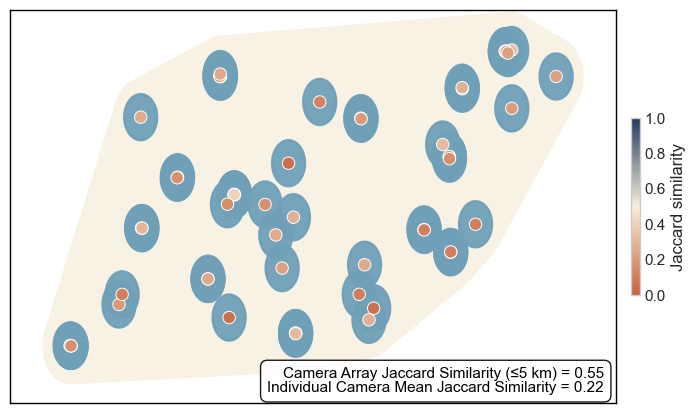

In [326]:
# -----------------------------
# 6. Plot
# -----------------------------
small_buffer_m = 600      # bigger camera circles
hull_expand_m = 1000      # soft expansion around boundary
SLOT_BOXB = (7.37, 4.0)

# Camera buffers
cams_buffer = cams_in_array.copy()
cams_buffer["geometry"] = cams_buffer.geometry.centroid.buffer(small_buffer_m)

# More natural array boundary using concave hull
array_hull = cams_in_array.copy()
array_hull["geometry"] = array_hull.geometry.centroid

try:
    array_hull_geom = array_hull.geometry.union_all().concave_hull(ratio=0.9)
except:
    array_hull_geom = array_hull.geometry.union_all().convex_hull

array_hull_geom = array_hull_geom.buffer(hull_expand_m)

array_natural_hull = gpd.GeoDataFrame(
    {"geometry": [array_hull_geom]},
    crs=cams_in_array.crs
)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=SLOT_BOXB)

# Array natural hull
array_natural_hull.plot(
    ax=ax,
    facecolor="#F3ECD5",
    edgecolor="none",
    alpha=0.65
)

# Camera outer circles
cams_buffer.plot(
    ax=ax,
    facecolor="#6FA0B8",
    edgecolor="#6FA0B8",
    linewidth=1.6,
    alpha=0.95
)

# Camera center points colored by Jaccard
cams_center = cams_in_array.copy()
cams_center["geometry"] = cams_center.geometry.centroid

cams_center.plot(
    ax=ax,
    column="jaccard",
    cmap=CMAP_AGREE,
    markersize=80,
    edgecolor="white",
    linewidth=0.7,
    legend=True,
    vmin=0,
    vmax=1,
    legend_kwds={
        "label": "Jaccard similarity",
        "orientation": "vertical",
        "shrink": 0.45,
        "pad": 0.02
    }
)

# -----------------------------
# Zoom (less top empty space)
# -----------------------------
xmin, ymin, xmax, ymax = array_natural_hull.total_bounds

xr = xmax - xmin
yr = ymax - ymin

padx = xr * 0.06
pady_bottom = yr * 0.05
pady_top = yr * 0.005

ax.set_xlim(xmin - padx, xmax + padx)
ax.set_ylim(ymin - pady_bottom, ymax + pady_top)


# -----------------------------
# Summary box
# -----------------------------
summary_text = (
    f"Camera Array Jaccard Similarity (≤5 km) = {array_j:.2f}\n"
    f"Individual Camera Mean Jaccard Similarity = {mean_cam_j:.2f}"
)

ax.text(
    0.98, 0.02,                     # inside lower-left corner
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    multialignment="right",
    fontsize=11,
    fontname="Arial",
    color="black",
    linespacing=1,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.90,
        boxstyle="round,pad=0.45"
    )
)

# -----------------------------
# Styling
# -----------------------------
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("auto")
ax.margins(0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("black")

plt.tight_layout(pad=0.2)
plt.show()

In [274]:
# Herrera array geometry in original CRS
herrera = array_iucn[
    array_iucn["Camera_Trap_Array"].str.contains("Herrera", case=False, na=False)
].copy()

# Keep one geometry
herrera = herrera.drop_duplicates("Camera_Trap_Array")

# Convert to WGS84 lat/lon
herrera_ll = herrera.to_crs(4326)

# Centroid
herrera_ll["centroid"] = herrera_ll.geometry.centroid

# Longitude / Latitude
herrera_ll["longitude"] = herrera_ll["centroid"].x
herrera_ll["latitude"] = herrera_ll["centroid"].y

print(
    herrera_ll[
        ["Camera_Trap_Array", "longitude", "latitude"]
    ]
)

    Camera_Trap_Array  longitude   latitude
105           Herrera -77.041313  38.896516


/var/folders/dx/fz7lq92d3zz2d72jhk9_rryr0000gn/T/ipykernel_65983/1215362771.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  herrera_ll["centroid"] = herrera_ll.geometry.centroid
